# Phase 2B. Leave-One-TMC-Out Spatial Generalization

Multi-year LOTO evaluation using the combined 2022–2025 gold table. Focused on XGBoost and persistence. Exports result tables and paper-ready figures.

In [ ]:

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

GOLD_PATH = r"..\..\..\Data\c_final_tables\baseline_model_gold_table\I66_phase1_TTI_features_2022_2025_combined.parquet"
OUTPUT_DIR = r"..\..\..\notebooks\modelling\project_1_output\phase2_loto_2022_2025"

os.makedirs(OUTPUT_DIR, exist_ok=True)

target_column = "target_tti_30min_ahead"   # recommended paper focus
train_end_date = "2024-12-31 23:59:59+00:00"
validation_end_date = "2025-06-30 23:59:59+00:00"

# computational controls
sample_training_fraction = 0.35   # reduce if memory/time is too high, increase if you want fuller training
minimum_train_rows = 50000
minimum_test_rows = 200

xgboost_parameters = {
    "n_estimators": 300,
    "max_depth": 6,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": 42,
    "n_jobs": -1,
    "tree_method": "hist",
}


In [2]:

gold_dataframe = pd.read_parquet(GOLD_PATH).copy()
gold_dataframe["ts_utc"] = pd.to_datetime(gold_dataframe["ts_utc"], utc=True)
gold_dataframe = gold_dataframe[gold_dataframe["ts_local"].dt.year <= 2025].copy()
gold_dataframe = gold_dataframe.sort_values(["tmc", "direction", "ts_utc"]).reset_index(drop=True)

if "sin_hour" not in gold_dataframe.columns or "cos_hour" not in gold_dataframe.columns:
    gold_dataframe["hour"] = gold_dataframe["ts_utc"].dt.hour
    gold_dataframe["sin_hour"] = np.sin(2 * np.pi * gold_dataframe["hour"] / 24)
    gold_dataframe["cos_hour"] = np.cos(2 * np.pi * gold_dataframe["hour"] / 24)

if "sin_day_of_week" not in gold_dataframe.columns or "cos_day_of_week" not in gold_dataframe.columns:
    gold_dataframe["day_of_week"] = gold_dataframe["ts_utc"].dt.dayofweek
    gold_dataframe["sin_day_of_week"] = np.sin(2 * np.pi * gold_dataframe["day_of_week"] / 7)
    gold_dataframe["cos_day_of_week"] = np.cos(2 * np.pi * gold_dataframe["day_of_week"] / 7)

if "sin_month" not in gold_dataframe.columns or "cos_month" not in gold_dataframe.columns:
    gold_dataframe["month"] = gold_dataframe["ts_utc"].dt.month
    gold_dataframe["sin_month"] = np.sin(2 * np.pi * (gold_dataframe["month"] - 1) / 12)
    gold_dataframe["cos_month"] = np.cos(2 * np.pi * (gold_dataframe["month"] - 1) / 12)

if "is_weekend_flag" not in gold_dataframe.columns:
    gold_dataframe["is_weekend_flag"] = (gold_dataframe["ts_utc"].dt.dayofweek >= 5).astype(int)

feature_columns = [
    col for col in gold_dataframe.columns
    if col.startswith("tti_lag_")
    or col.startswith("tti_rolling_")
    or col in [
        "tti_change_1_step",
        "tti_absolute_change_1_step",
        "is_low_confidence_flag",
        "sin_hour",
        "cos_hour",
        "sin_day_of_week",
        "cos_day_of_week",
        "sin_month",
        "cos_month",
        "is_weekend_flag",
    ]
]

gold_dataframe = gold_dataframe.dropna(subset=[target_column]).copy()
gold_dataframe = gold_dataframe.dropna(subset=feature_columns).copy()
gold_dataframe["calendar_year"] = gold_dataframe["ts_utc"].dt.year

print(gold_dataframe.shape)
print("Target:", target_column)
print("Number of TMC-direction groups:", gold_dataframe[["tmc", "direction"]].drop_duplicates().shape[0])


(17229104, 45)
Target: target_tti_30min_ahead
Number of TMC-direction groups: 41


In [3]:

def calculate_regression_metrics(true_values, predicted_values):
    mae_value = mean_absolute_error(true_values, predicted_values)
    rmse_value = np.sqrt(mean_squared_error(true_values, predicted_values))
    return {"mae": float(mae_value), "rmse": float(rmse_value)}

def train_xgboost_regressor(training_features, training_target, model_parameters):
    model = XGBRegressor(**model_parameters)
    model.fit(training_features, training_target)
    return model


In [4]:

loto_results = []

unique_groups = (
    gold_dataframe[["tmc", "direction"]]
    .drop_duplicates()
    .sort_values(["direction", "tmc"])
    .reset_index(drop=True)
)

for _, row in unique_groups.iterrows():
    held_out_tmc = row["tmc"]
    held_out_direction = row["direction"]

    train_dataframe = gold_dataframe[
        (
            (gold_dataframe["tmc"] != held_out_tmc) |
            (gold_dataframe["direction"] != held_out_direction)
        ) &
        (gold_dataframe["ts_utc"] <= train_end_date)
    ].copy()

    test_dataframe = gold_dataframe[
        (gold_dataframe["tmc"] == held_out_tmc) &
        (gold_dataframe["direction"] == held_out_direction) &
        (gold_dataframe["ts_utc"] > validation_end_date)
    ].copy()

    if len(train_dataframe) < minimum_train_rows or len(test_dataframe) < minimum_test_rows:
        continue

    if sample_training_fraction < 1.0:
        train_dataframe = train_dataframe.sample(frac=sample_training_fraction, random_state=42)

    X_train = train_dataframe[feature_columns]
    y_train = train_dataframe[target_column]

    X_test = test_dataframe[feature_columns]
    y_test = test_dataframe[target_column]

    persistence_predictions = test_dataframe["tti"].to_numpy()
    persistence_metrics = calculate_regression_metrics(y_test, persistence_predictions)

    model = train_xgboost_regressor(X_train, y_train, xgboost_parameters)
    loto_predictions = model.predict(X_test)
    loto_metrics = calculate_regression_metrics(y_test, loto_predictions)

    loto_results.append({
        "tmc": held_out_tmc,
        "direction": held_out_direction,
        "n_train": len(train_dataframe),
        "n_test": len(test_dataframe),
        "mae_persistence": persistence_metrics["mae"],
        "rmse_persistence": persistence_metrics["rmse"],
        "mae_loto_xgb": loto_metrics["mae"],
        "rmse_loto_xgb": loto_metrics["rmse"],
        "mae_improvement_loto_xgb": persistence_metrics["mae"] - loto_metrics["mae"],
        "rmse_improvement_loto_xgb": persistence_metrics["rmse"] - loto_metrics["rmse"],
    })

loto_results_dataframe = pd.DataFrame(loto_results)
loto_results_dataframe.head()


,tmc,direction,n_train,n_test,mae_persistence,rmse_persistence,mae_loto_xgb,rmse_loto_xgb,mae_improvement_loto_xgb,rmse_improvement_loto_xgb
0,110-04163,EASTBOUND,4411960,52988,0.129878,0.407024,0.127289,0.359024,0.002589,0.048000
1,110-04164,EASTBOUND,4411949,52988,0.082892,0.294013,0.084354,0.300841,-0.001462,-0.006828
2,110-04165,EASTBOUND,4411976,52988,0.058828,0.182827,0.065855,0.284622,-0.007027,-0.101795
3,110-04166,EASTBOUND,4411942,52988,0.139402,0.273373,0.144705,0.267513,-0.005303,0.005861
4,110-04167,EASTBOUND,4411936,52988,0.294825,0.645053,0.294528,0.626197,0.000297,0.018856


In [5]:

overall_results = pd.DataFrame([{
    "horizon": target_column.replace("target_tti_", "").replace("_ahead", ""),
    "groups_evaluated": len(loto_results_dataframe),
    "mean_mae_persistence": loto_results_dataframe["mae_persistence"].mean(),
    "mean_rmse_persistence": loto_results_dataframe["rmse_persistence"].mean(),
    "mean_mae_loto_xgb": loto_results_dataframe["mae_loto_xgb"].mean(),
    "mean_rmse_loto_xgb": loto_results_dataframe["rmse_loto_xgb"].mean(),
    "mean_mae_improvement_loto_xgb": loto_results_dataframe["mae_improvement_loto_xgb"].mean(),
    "median_mae_improvement_loto_xgb": loto_results_dataframe["mae_improvement_loto_xgb"].median(),
    "groups_where_loto_beats_persistence": int((loto_results_dataframe["mae_improvement_loto_xgb"] > 0).sum()),
}])

overall_results


,horizon,groups_evaluated,mean_mae_persistence,mean_rmse_persistence,mean_mae_loto_xgb,mean_rmse_loto_xgb,mean_mae_improvement_loto_xgb,median_mae_improvement_loto_xgb,groups_where_loto_beats_persistence
0,30min,41,0.149329,0.431305,0.144145,0.390886,0.005184,0.002589,25


In [6]:

train_subset = gold_dataframe[gold_dataframe["ts_utc"] <= train_end_date].copy()

volatility_results = (
    train_subset
    .groupby(["tmc", "direction"], as_index=False)["tti"]
    .std()
    .rename(columns={"tti": "tti_volatility"})
)

volatility_results = volatility_results.merge(loto_results_dataframe, on=["tmc", "direction"], how="inner")
volatility_correlation = volatility_results[["tti_volatility", "mae_improvement_loto_xgb"]].corr()
volatility_correlation


,tti_volatility,mae_improvement_loto_xgb
tti_volatility,1.00000,0.34164
mae_improvement_loto_xgb,0.34164,1.00000


In [7]:

overall_results.to_csv(os.path.join(OUTPUT_DIR, "loto_overall_results.csv"), index=False)
loto_results_dataframe.to_csv(os.path.join(OUTPUT_DIR, "loto_per_tmc_results.csv"), index=False)
volatility_results.to_csv(os.path.join(OUTPUT_DIR, "loto_volatility_results.csv"), index=False)

paper_summary_table = overall_results.copy()
paper_summary_table.to_csv(os.path.join(OUTPUT_DIR, "loto_paper_summary_table.csv"), index=False)

print("Saved CSV files to:", OUTPUT_DIR)


Saved CSV files to: ..\..\..\notebooks\modelling\model_outputs\Phase_1_model\phase2_loto_2022_2025


## Paper-ready figures

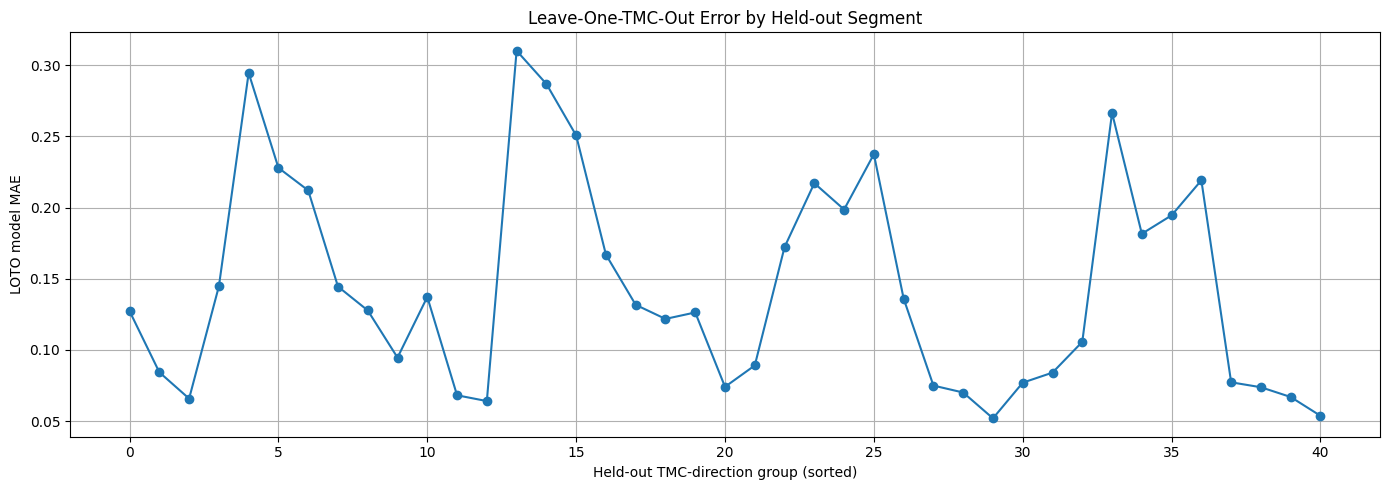

In [8]:

# Figure 1. LOTO MAE by TMC-direction
plot_dataframe = loto_results_dataframe.sort_values(["direction", "tmc"]).reset_index(drop=True)

plt.figure(figsize=(14, 5))
plt.plot(plot_dataframe.index, plot_dataframe["mae_loto_xgb"], marker="o")
plt.xlabel("Held-out TMC-direction group (sorted)")
plt.ylabel("LOTO model MAE")
plt.title("Leave-One-TMC-Out Error by Held-out Segment")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "figure_loto_mae_by_tmc.png"), dpi=300, bbox_inches="tight")
plt.show()


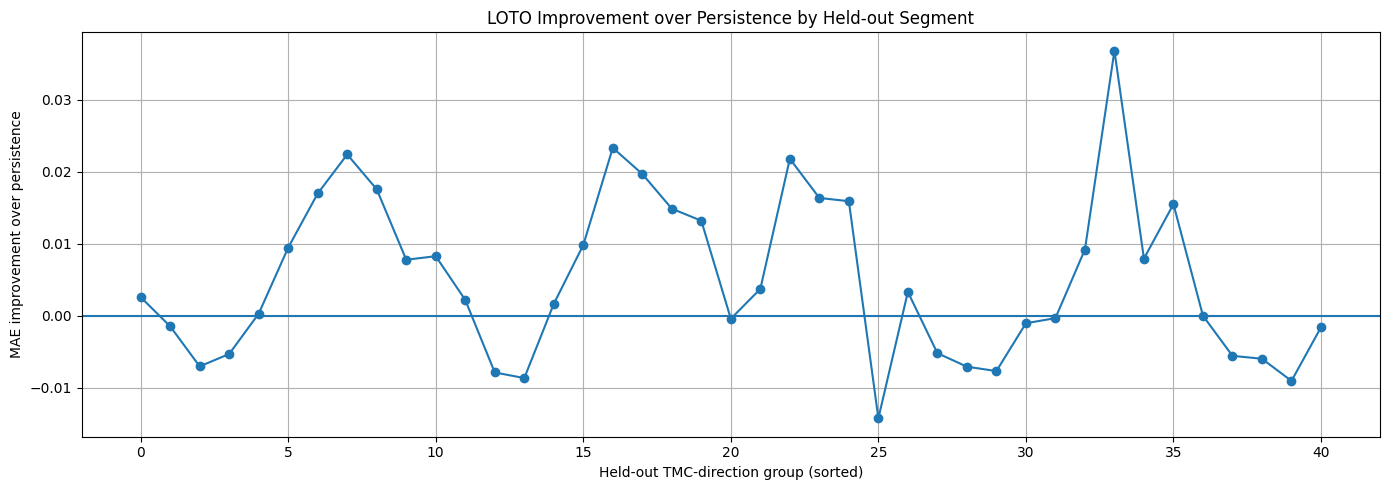

In [9]:

# Figure 2. LOTO improvement by TMC-direction
plot_dataframe = loto_results_dataframe.sort_values(["direction", "tmc"]).reset_index(drop=True)

plt.figure(figsize=(14, 5))
plt.plot(plot_dataframe.index, plot_dataframe["mae_improvement_loto_xgb"], marker="o")
plt.axhline(0)
plt.xlabel("Held-out TMC-direction group (sorted)")
plt.ylabel("MAE improvement over persistence")
plt.title("LOTO Improvement over Persistence by Held-out Segment")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "figure_loto_improvement_by_tmc.png"), dpi=300, bbox_inches="tight")
plt.show()


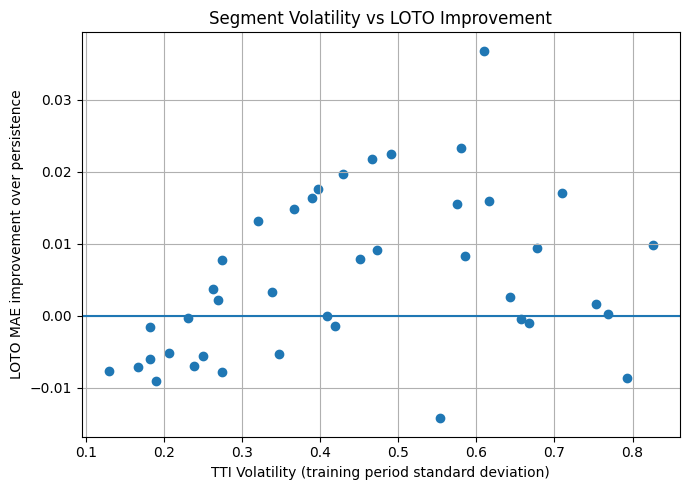

In [10]:

# Figure 3. Volatility vs LOTO improvement
plt.figure(figsize=(7, 5))
plt.scatter(volatility_results["tti_volatility"], volatility_results["mae_improvement_loto_xgb"])
plt.axhline(0)
plt.xlabel("TTI Volatility (training period standard deviation)")
plt.ylabel("LOTO MAE improvement over persistence")
plt.title("Segment Volatility vs LOTO Improvement")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "figure_loto_volatility_vs_improvement.png"), dpi=300, bbox_inches="tight")
plt.show()
